<p style="text-align:center">

</p>


# Project: Model Development - Laptop Pricinig 



In this project, we will use linear regression principles to create a model that predicts the Price of the laptop, based on one or more attributes of the dataset.


# Objectives



 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


# Setup


For this project, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __We will need to run the following cell__ to install them:


In [1]:
import piplite
await piplite.install('seaborn')

### Importing Required Libraries



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

<ipython-input-2-c5c9fedd4c6a>:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Importing the dataset
Download the dataset into this environment.

This function will download the dataset into the browser


In [3]:
#This function will download the dataset into the browser 

from pyodide.http import pyfetch

async def download(url, filename):
    response = await pyfetch(url)
    if response.status == 200:
        with open(filename, "wb") as f:
            f.write(await response.bytes())

We put the file path along with a quotation mark so that pandas will read the file into a dataframe from that address. The file path can be either an URL or our local file address.


In [5]:
path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"

Download the dataset using the download() function:


In [6]:
#Download the dataset;
await download(path, "laptops.csv")
file_name="laptops.csv"

Load the dataset into a pandas dataframe


In [7]:
df = pd.read_csv(file_name, header=0)

>Note: This version of the project is working on JupyterLite, which requires the dataset to be downloaded to the interface.While working on the downloaded version of this notebook on their local machines(Jupyter Anaconda), we can simply skip the steps above, and simply use the URL directly in the pandas.read_csv() function. Uncomment and run the statements in the cell below.


In [ ]:
#https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv"
#df = pd.read_csv(filepath, header=None)

In [8]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Model Development 1 : Single Linear Regression

We have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset in my previous project. Now, we create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.


In [11]:
X = df[["CPU_frequency"]]
Y = df[["Price"]]
lm = LinearRegression()
lm.fit(X,Y)
yhat = lm.predict(X)
yhat[0:5]

array([[1073.07834392],
       [1277.93263722],
       [1636.42765051],
       [1073.07834392],
       [1175.50549057]])

In [12]:
lm.coef_

array([[1485.19362648]])

In [13]:
lm.intercept_

array([253.66117069])

Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


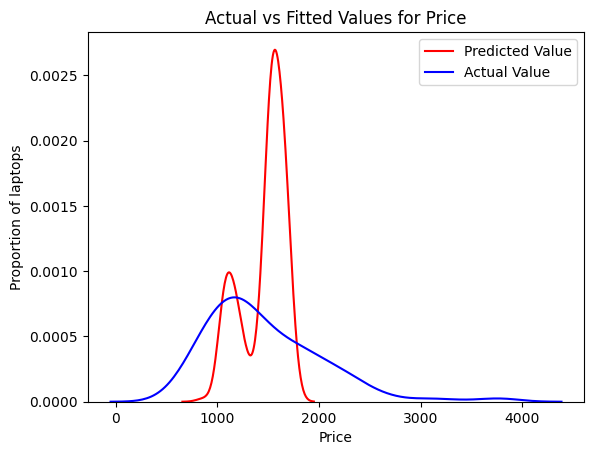

In [16]:
ax1 = sns.distplot(yhat,hist = False,color="r",label="Predicted Value")
sns.distplot(df[["Price"]],hist=False,color="b",label="Actual Value",ax=ax1)

plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Predicted Value','Actual Value'])
plt.show()

Evaluate the Mean Squared Error and R^2 score values for the model. 


In [20]:
mse_slr = mean_squared_error(Y,yhat)
mse_slr

284583.44058686297

In [21]:
r2_slr = lm.score(X,Y)
r2_slr

0.13444363210243238

# Model Development 2 - Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category' as suggested in my previous project. Use all these variables to create a Multiple Linear Regression system. 


In [22]:
Z = df[["CPU_frequency","RAM_GB","Storage_GB_SSD","CPU_core","OS","GPU","Category"]]
lm_mlr = LinearRegression()
lm_mlr.fit(Z,Y)
yhat_mlr = lm_mlr.predict(Z)
yhat_mlr[0:5]

array([[1345.51622771],
       [ 710.44905496],
       [1552.37242687],
       [1295.00681012],
       [1543.13847022]])

Plot the Distribution graph of the predicted values as well as the Actual values


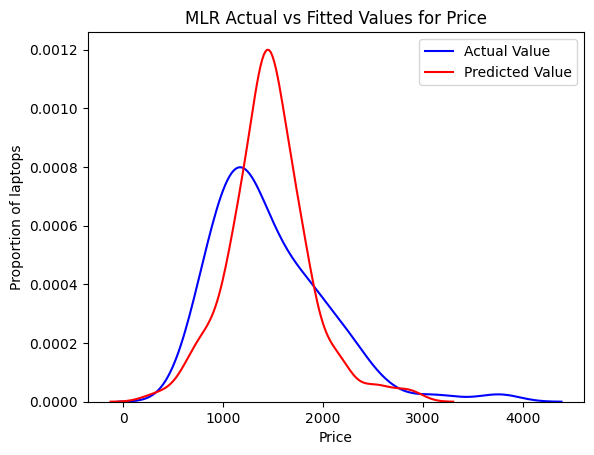

In [24]:
ax2 = sns.distplot(Y,hist=False,color="b",label="Actual Value")
sns.distplot(yhat_mlr,hist=False,color="r",label="Predicted Value")

plt.title('MLR Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend(['Actual Value','Predicted Value'])
plt.show()

Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [25]:
mse_mlr = mean_squared_error(Y,yhat_mlr)
mse_mlr

161680.57263893107

In [26]:
r2_mlr = lm_mlr.score(Z,Y)
r2_mlr

0.5082509055187374

The MSE of MLR is smaller than MSE of the SLR; The R2 of the MLR is larger than that of the SLR; \
thus, the MLR model seems to perform better than the SLR model

# Model Development 3 - Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Polynomial fits are done using `numpy.polyfit`. 


In [37]:
X_cpu = df["CPU_frequency"]
Y = df["Price"]
f1 = np.polyfit(X_cpu,Y,1)
p1 = np.poly1d(f1)
print(p1)

 
1485 x + 253.7


In [32]:
f3 = np.polyfit(X_cpu,Y,3)
p3 = np.poly1d(f3)
print(p3)

           3             2
3.409e+04 x - 6.574e+04 x + 4.129e+04 x - 7238


In [38]:
f5 = np.polyfit(X_cpu,Y,5)
p5 = np.poly1d(f5)
print(p5)

           5            4             3             2
1.357e+06 x - 4.72e+06 x + 6.458e+06 x - 4.336e+06 x + 1.425e+06 x - 1.818e+05


Plot the regression output against the actual data points to note how the data fits in each case.


In [34]:
def PlotPolly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(independent_variable.min(),independent_variable.max(),100)
    y_new = model(x_new)

    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title(f'Polynomial Fit for Price ~ {Name}')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    fig = plt.gcf()
    plt.xlabel(Name)
    plt.ylabel('Price of laptops')

Call this function for the 3 models created and get the required graphs.


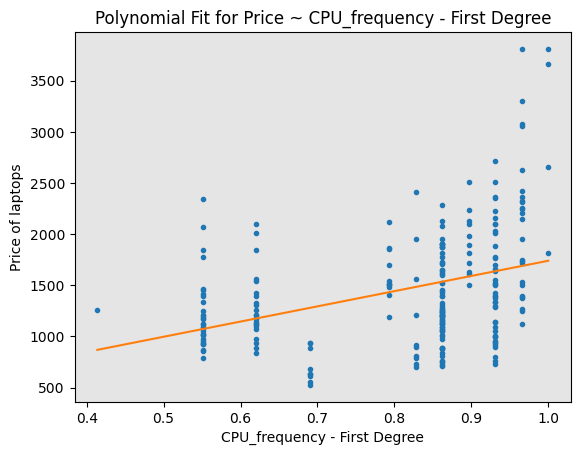

In [42]:
# Call for function of degree 1
PlotPolly(p1,X_cpu,Y,"CPU_frequency - First Degree")

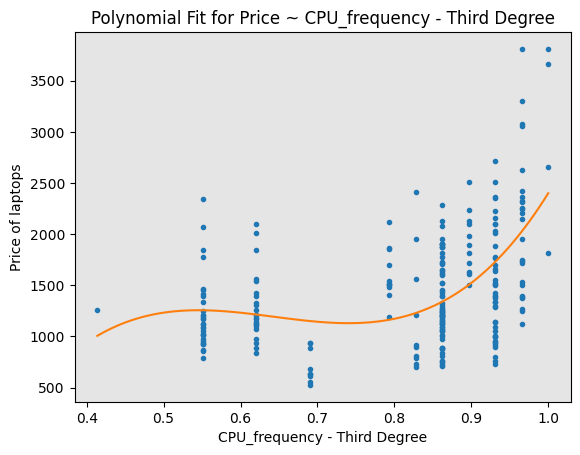

In [41]:
# Call for function of degree 3
PlotPolly(p3,X_cpu,Y,"CPU_frequency - Third Degree")

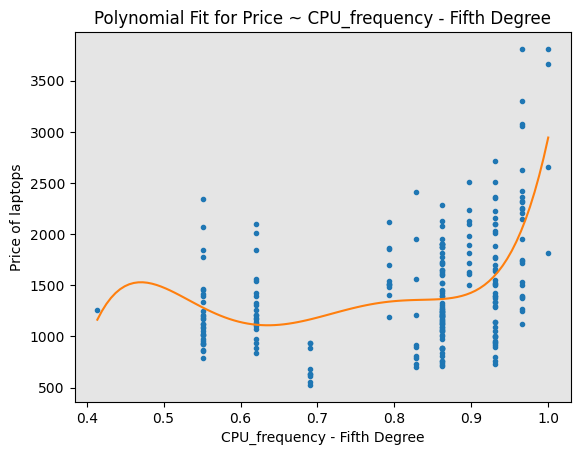

In [43]:
# Call for function of degree 5
PlotPolly(p5,X_cpu,Y,"CPU_frequency - Fifth Degree")

Also, calculate the R^2 and MSE values for these fits. For polynomial functions, the function sklearn.metrics.r2_score will be used to calculate R^2 values.


In [46]:
mse_poly1 = mean_squared_error(Y,p1(X_cpu))
print("MSE value for 1st degree polynomial function: ",mse_poly1)
r2_poly1 = r2_score(Y,p1(X_cpu))
print("R2 value for 1st degree polynomial function: ",r2_poly1)

MSE value for 1st degree polynomial function:  284583.4405868628
R2 value for 1st degree polynomial function:  0.13444363210243282


In [47]:
mse_poly3 = mean_squared_error(Y,p3(X_cpu))
print("MSE value for 3rd degree polynomial function: ",mse_poly3)
r2_poly3 = r2_score(Y,p3(X_cpu))
print("R2 value for 3rd degree polynomial function: ",r2_poly3)

MSE value for 3rd degree polynomial function:  241024.8630384881
R2 value for 3rd degree polynomial function:  0.26692640796530986


In [48]:
mse_poly5 = mean_squared_error(Y,p5(X_cpu))
print("MSE value for 5th degree polynomial function: ",mse_poly5)
r2_poly5 = r2_score(Y,p5(X_cpu))
print("R2 value for 5th degree polynomial function: ",r2_poly5)

MSE value for 5th degree polynomial function:  229137.29548053825
R2 value for 5th degree polynomial function:  0.3030822706443803


# Model Development 4 - Pipeline
Then, we create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. We use the set of multiple features as before to create this pipeline. 


In [57]:
Input = [("scale",StandardScaler()),("polynomial",PolynomialFeatures(degree=2,include_bias=False)),("Model",LinearRegression())]
Pipe = Pipeline(Input)
Z = Z.astype("float")
Pipe.fit(Z,Y)
yhat_pipe = Pipe.predict(Z)
yhat_pipe[0:5]

array([1371. , 1159.5, 1389. ,  -52.5, 1602.5])

Evaluate the MSE and R^2 values for the this predicted output.


In [58]:
mse_pipe = mean_squared_error(Y,yhat_pipe)
r2 = r2_score(Y,yhat_pipe)
print("MSE value for pipelined model is: ",mse_poly5)
print("R2 value for pipelined model is: ",r2_poly5)

MSE value for pipelined model is:  229137.29548053825
R2 value for pipelined model is:  0.3030822706443803


We now see that the values of R^2 increase as we go from Single Linear Regression to Multiple Linear Regression. Further, if we go for multiple linear regression extended with polynomial features, we get an even better R^2 value.
